#Упражнения: Раздел 8

In [47]:
# Get thinkdsp.py

import os

if not os.path.exists('thinkdsp.py'):
    !wget https://github.com/Dementrrr/ThinkDSP/raw/master/code/thinkdsp.py

import thinkdsp as tdsp
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import windows as spsig

##Упражнение 8.1
Немного работы с главой

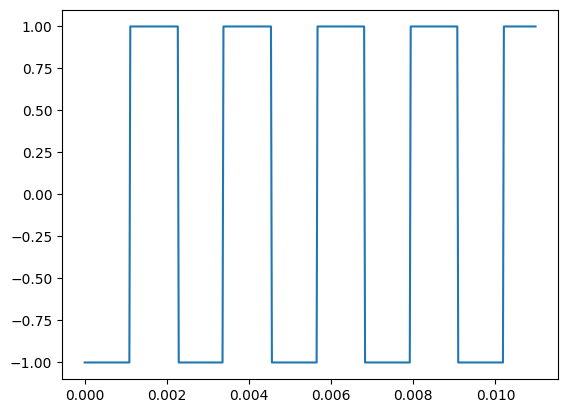

In [33]:
sig = tdsp.SquareSignal()
wave = sig.make_wave(duration=0.011, framerate=44100)
wave.plot()

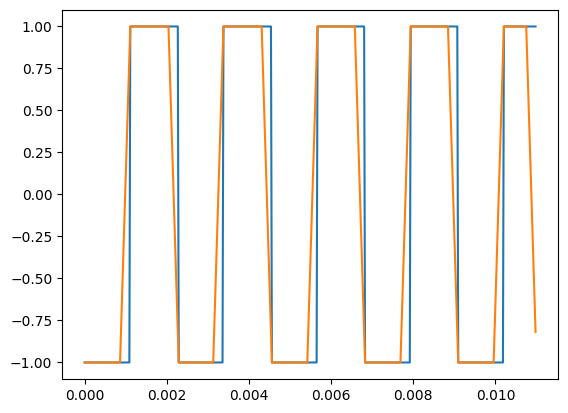

In [34]:
def smooth(wave, winlength=11):
  ys = wave.ys
  N = len(ys)
  smoothed = np.zeros(N)

  window = np.ones(winlength)
  window /= sum(window)

  padded = tdsp.zero_pad(window, N)
  rolled = padded
  for i in range(N):
    smoothed[i]= sum(rolled*ys)
    rolled = np.roll(rolled, 1)

  new_wave = tdsp.Wave(ys=smoothed, ts=wave.ts, framerate=wave.framerate)
  return new_wave

new_wave = smooth(wave)
wave.plot()
new_wave.plot()


##Упражнение 8.2
ДПФ для гауссовой кривой

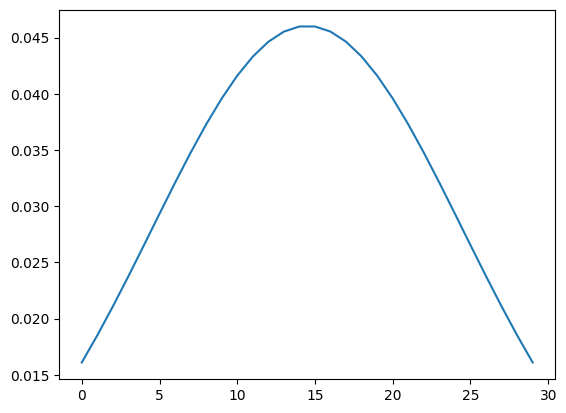

In [66]:
#гауссово окно
gaussian = spsig.gaussian(M=30, std=10)
gaussian /= sum(gaussian)
plt.plot(gaussian)


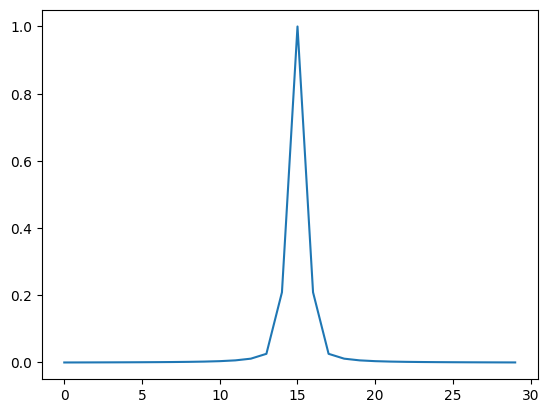

In [67]:
#ДПФ
fft_gaussian = np.fft.fft(gaussian)
N = len(gaussian)
#переместим половину значений
fft_gaussian = np.roll(fft_gaussian, N//2)
plt.plot(abs(fft_gaussian))

Чем больше std для начального окна, тем уже конечное окно

##Упражнение 8.3
Изучение ДПФ окон Хэмминга, Гаусса и Бартлетта

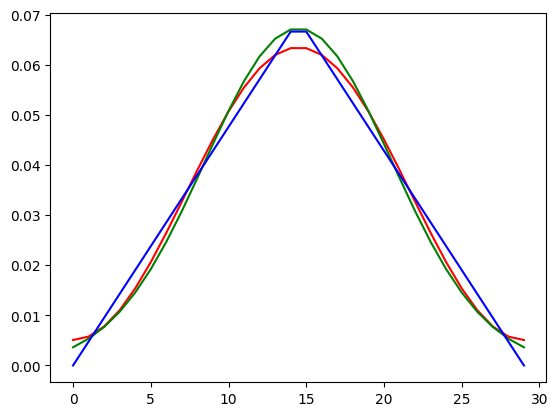

In [92]:
#сигнал для работы
signal = tdsp.SquareSignal()
wave = signal.make_wave(duration=0.01, framerate=44100)

#создадим окна
M = 30
std = 6

hamming = np.hamming(M)
gaussian = spsig.gaussian(M, std)
bartlett = np.bartlett(M)

windows = [hamming, gaussian, bartlett]
colors = ['red', 'green', 'blue']
for window in windows:
    window /= sum(window)

#отрисуем окна
for window, color in zip(windows, colors):
    plt.plot(window, color)


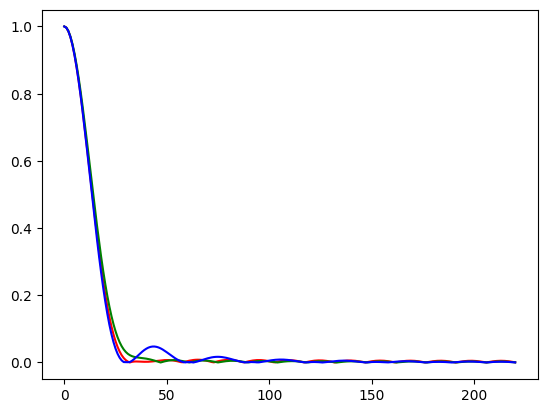

In [93]:
#ДПФ окон
for window, color in zip(windows, colors):
        padded = tdsp.zero_pad(window, len(wave))
        dft_window = np.fft.rfft(padded)
        plt.plot(abs(dft_window), color)

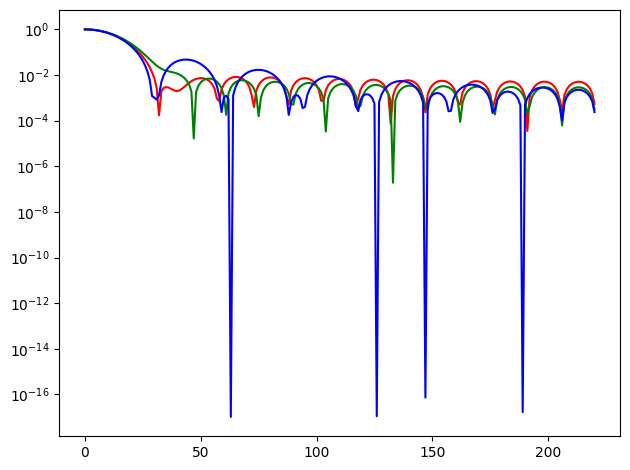

In [97]:
#ДПФ в логарифмическом масштабе
for window, color in zip(windows, colors):
        padded = tdsp.zero_pad(window, len(wave))
        dft_window = np.fft.rfft(padded)
        plt.plot(abs(dft_window), color)
        tdsp.decorate(yscale='log')

Можем заметить, что все три окна имеют боковые лепестки. Окно Бартлетта спадает быстрее остальных, соответственно из выбранных лучше всего подходит для фильтра НЧ.